In [1]:
# %pip install numpy matplotlib

### Importação das Bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos Dados com CSV

In [3]:
try: 
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows
    # Coluna 5 = sqft_living (área do imóvel, será X) e coluna 2 = price (valor do imóvel, será Y)
    dados = np.loadtxt('kc_house_data.csv', delimiter=',', skiprows=1, usecols=(5, 2)) 
except FileNotFoundError:
    print("Erro: arquivo 'dataset.csv' não encontrado")
    print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
    exit()

In [4]:
# apenas visualiza os dados carregados do arquivo CSV
print(dados)

[[  1180. 221900.]
 [  2570. 538000.]
 [   770. 180000.]
 ...
 [  1020. 402101.]
 [  1600. 400000.]
 [  1020. 325000.]]


### Separando os dados e X e Y

In [5]:
x = dados[:, 0] # sqft_living: área construída do imóvel (característica)
y = dados[:, 1] # price: valor do imóvel (o que queremos explicar/prever)

# Visualiza os dados
print('X (área em sqft):', x)
print('Y (preço em US$):', y)

print("\nNúmero de amostras: ", x.shape[0])

X (área em sqft): [1180. 2570.  770. ... 1020. 1600. 1020.]
Y (preço em US$): [221900. 538000. 180000. ... 402101. 400000. 325000.]

Número de amostras:  21613


In [6]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print('X:', x)
print('\nY:', y)

# Descomente a linha abaixo se quiser ver detalhes dos dados

#print('Número de características:', x.reshape[1])
#print('Número de saídas)

X: [[1180.]
 [2570.]
 [ 770.]
 ...
 [1020.]
 [1600.]
 [1020.]]

Y: [[221900.]
 [538000.]
 [180000.]
 ...
 [402101.]
 [400000.]
 [325000.]]


### Calculando 'A' e 'B'

In [7]:
# Calcular os coeficientes da regressão linear (A e B)
x_mean = np.mean(x)
y_mean = np.mean(y)

print('Média de X (área em sqft):', x_mean)
print('Média de Y (preço em US$):', y_mean)

Média de X (área em sqft): 2079.8997362698374
Média de Y (preço em US$): 540088.1417665294


In [8]:
def predict(x_novo, _m, _b):
    """
    Prevê novos valores de y com base nos coeficientes da regressão.
    Args:
        x_novo: Um número ou array NumPy com os novos valores de x.
        m: Coeficiente angular (slope) do modelo.
        b: O intercepto do modelo
    Returns: O(s) valor(es) de y previstos
    """
    return _m * x_novo + _b

Coeficientes calculados a partir do CSV: 
Coeficiente angular (m): 280.6236
Intercepto (b) -43580.7431

Equação da linha: preco = 280.6236 * area_sqft + -43580.7431

Coeficiente de Determinação (R²): 0.4929
O modelo tem um ajuste fraco


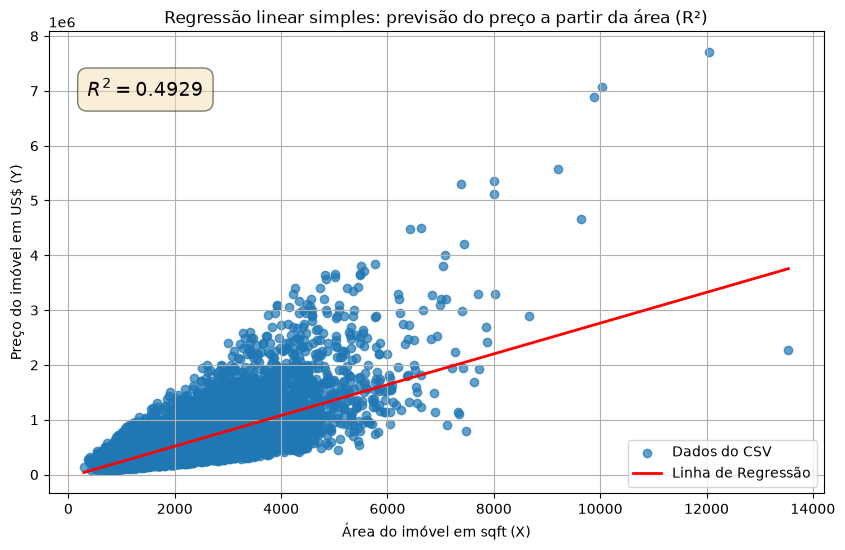

In [9]:
m = len(x)
numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)

m = numerador / denominador
b = y_mean - (m * x_mean)

# Fazer as previsões do modelo
# Para cada valor de x, calculamos o y previsto (^y) pela nossa linha.
y_pred = m * x + b

# Calcular o R-quadrado (R²) para avaliar o modelo 
sqr = np.sum((y - y_pred) ** 2) # Soma quadrática dos resíduos
sqt = np.sum((y - y_mean) ** 2) # Soma quadrática total
r2 = 1 - (sqr / sqt)

# Imprimir os resultados
print(f"Coeficientes calculados a partir do CSV: ")
print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b) {b:.4f}")
print("\nEquação da linha: preco = {:.4f} * area_sqft + {:.4f}".format(m, b))
print(f"\nCoeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print('O modelo tem um bom ajuste aos dados.')
elif r2 > 0.5:
    print('O modelo tem um ajuste moderado')
else:
    print('O modelo tem um ajuste fraco')

# Criar a linha de regressão para Visualização
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

# Visualizar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados do CSV', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

# Adiciona o valor R² ao gráfico para fácil visialização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title("Regressão linear simples: previsão do preço a partir da área (R²)")
plt.xlabel('Área do imóvel em sqft (X)')
plt.ylabel('Preço do imóvel em US$ (Y)')
plt.legend()
plt.grid(True)
plt.show()